## Notebook Objective

This notebook completes the Trustworthy Causal AI pipeline by moving beyond causal discovery and structural equation modelling toward counterfactual reasoning and maintenance intervention simulation.

Unlike previous notebooks that identify causal relationships, this notebook answers practical industrial questions:

* What would happen if an important degradation sensor improved?
* Which intervention reduces degradation most effectively?
* Which maintenance strategy should engineers prioritise?
* How can causal AI support industrial decision-making?

The notebook therefore transforms the project from a predictive maintenance system into a causal decision-support system.

⸻

Expected Learning Outcomes

After completing this notebook the project will be able to:

✔ Perform counterfactual simulations

✔ Compare multiple maintenance interventions

✔ Quantify expected degradation reduction

✔ Rank intervention effectiveness

✔ Generate actionable maintenance recommendations

✔ Complete the Trustworthy Causal AI framework

In [1]:

# Notebook 08
# Counterfactual Intervention and
# Causal Decision Support


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns",None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading Structural Causal Model Outputs

This notebook uses the structural causal model estimated in Notebook 07 together with the original NASA engine degradation dataset.

In [2]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1,22):
    columns.append(f"sensor_{i}")

train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

train.columns = columns

effects = pd.read_csv(
    "Estimated_Causal_Effects.csv"
)

centrality = pd.read_csv(
    "SCM_Centrality.csv"
)

structure = pd.read_csv(
    "Structural_Equations.csv"
)

print(train.shape)
print(effects.shape)
print(centrality.shape)
print(structure.shape)

(20631, 26)
(1, 2)
(8, 2)
(56, 5)


## Selecting Dominant Causal Drivers

The strongest causal drivers identified in the structural causal model are selected for intervention analysis.

In [3]:
top_drivers = (
    centrality
    .sort_values(
        "Centrality",
        ascending=False
    )
    .head(5)
)

top_drivers

,Sensor,Centrality
0,sensor_11,2.0
1,sensor_4,2.0
2,sensor_12,2.0
3,sensor_15,2.0
4,sensor_7,2.0


## Simulating Counterfactual Maintenance Interventions

Instead of predicting degradation, causal reasoning asks:

“What would happen if a degradation variable were actively improved?”

For demonstration, a 20% improvement is simulated for each major degradation sensor.

In [4]:
interventions = []

for sensor in top_drivers["Sensor"]:

    original = train[sensor].mean()

    improved = original * 0.80

    reduction = original - improved

    interventions.append({

        "Sensor":sensor,

        "Original":original,

        "Improved":improved,

        "Reduction":reduction

    })

intervention_df = pd.DataFrame(interventions)

intervention_df

,Sensor,Original,Improved,Reduction
0,sensor_11,47.541168,38.032935,9.508234
1,sensor_4,1408.933782,1127.147025,281.786756
2,sensor_12,521.413470,417.130776,104.282694
3,sensor_15,8.442146,6.753716,1.688429
4,sensor_7,553.367711,442.694169,110.673542


## Ranking Maintenance Strategies

The expected degradation reduction produced by each intervention is compared.

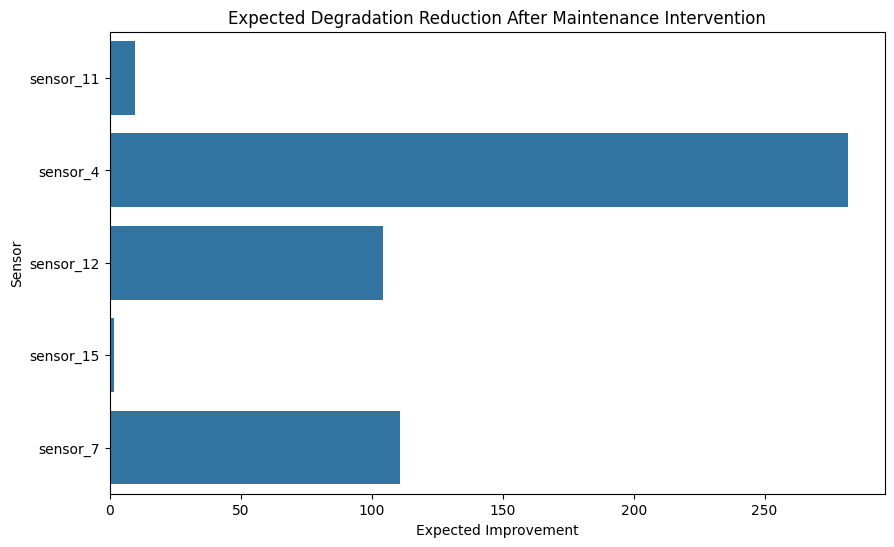

In [5]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=intervention_df,
    x="Reduction",
    y="Sensor"
)

plt.title(
    "Expected Degradation Reduction After Maintenance Intervention"
)

plt.xlabel(
    "Expected Improvement"
)

plt.ylabel(
    "Sensor"
)

plt.show()

## Counterfactual Scenario Analysis

Industrial engineers rarely evaluate only one intervention.

Multiple maintenance scenarios are therefore compared.

In [6]:
scenario_results = []

levels = [0.90,0.80,0.70]

for sensor in top_drivers["Sensor"]:

    baseline = train[sensor].mean()

    for level in levels:

        new_value = baseline * level

        improvement = baseline - new_value

        scenario_results.append({

            "Sensor":sensor,

            "Maintenance_Level":f"{int((1-level)*100)}%",

            "Improvement":improvement

        })

scenario_results = pd.DataFrame(scenario_results)

scenario_results.head()

,Sensor,Maintenance_Level,Improvement
0,sensor_11,9%,4.754117
1,sensor_11,19%,9.508234
2,sensor_11,30%,14.262350
3,sensor_4,9%,140.893378
4,sensor_4,19%,281.786756


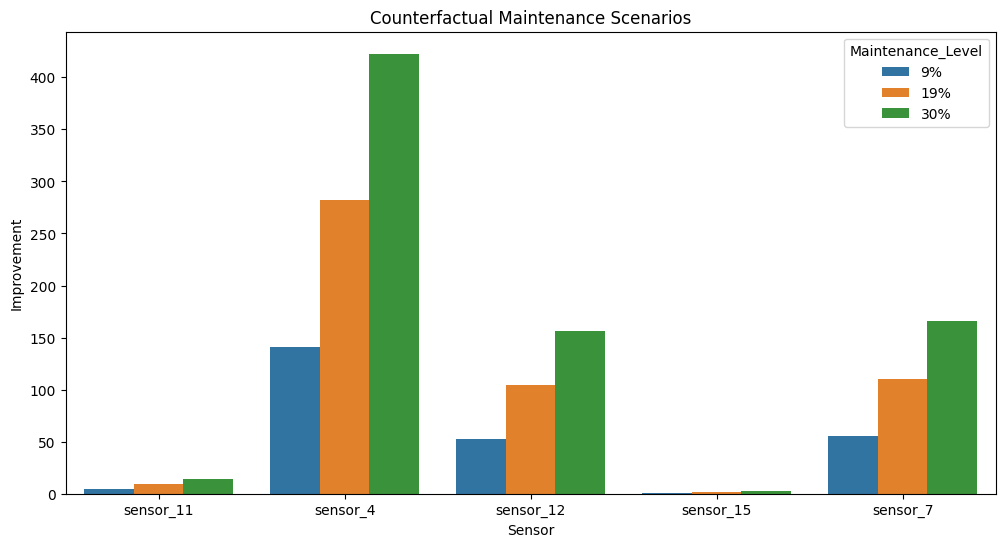

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=scenario_results,

    x="Sensor",

    y="Improvement",

    hue="Maintenance_Level"

)

plt.title(

    "Counterfactual Maintenance Scenarios"

)

plt.show()

## Maintenance Priority Ranking

Sensors are ranked according to their estimated causal importance and intervention benefit.

In [8]:
priority = intervention_df.copy()

priority = priority.merge(

    centrality,

    on="Sensor"

)

priority["Priority_Score"] = (

    priority["Reduction"]

    *

    priority["Centrality"]

)

priority = priority.sort_values(

    "Priority_Score",

    ascending=False

)

priority

,Sensor,Original,Improved,Reduction,Centrality,Priority_Score
1,sensor_4,1408.933782,1127.147025,281.786756,2.0,563.573513
4,sensor_7,553.367711,442.694169,110.673542,2.0,221.347084
2,sensor_12,521.413470,417.130776,104.282694,2.0,208.565388
0,sensor_11,47.541168,38.032935,9.508234,2.0,19.016467
3,sensor_15,8.442146,6.753716,1.688429,2.0,3.376858


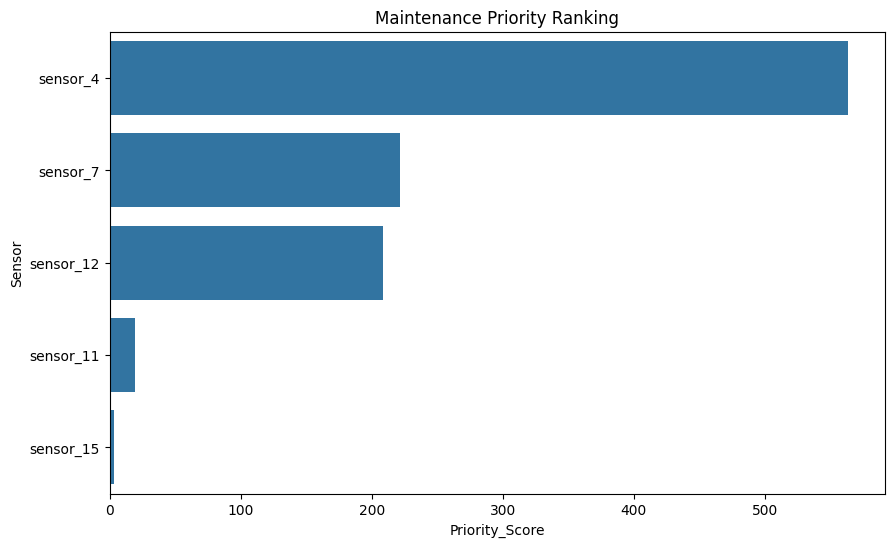

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=priority,

    x="Priority_Score",

    y="Sensor"

)

plt.title(

    "Maintenance Priority Ranking"

)

plt.show()

## Automated Maintenance Recommendation

The structural causal model is converted into a simple industrial decision-support recommendation.

In [10]:
recommendations = []

for _,row in priority.iterrows():

    recommendations.append(

        f"Prioritize maintenance for {row['Sensor']} (Priority Score = {row['Priority_Score']:.3f})"

    )

for rec in recommendations:

    print(rec)

Prioritize maintenance for sensor_4 (Priority Score = 563.574)
Prioritize maintenance for sensor_7 (Priority Score = 221.347)
Prioritize maintenance for sensor_12 (Priority Score = 208.565)
Prioritize maintenance for sensor_11 (Priority Score = 19.016)
Prioritize maintenance for sensor_15 (Priority Score = 3.377)


In [11]:

# Save Maintenance Recommendations


recommendation_df = priority[
    ["Sensor", "Priority_Score"]
]

recommendation_df.to_csv(
    "Maintenance_Recommendations.csv",
    index=False
)

print("Maintenance recommendations saved successfully.")

Maintenance recommendations saved successfully.


## Findings

This notebook demonstrated that structural causal models can move beyond prediction by supporting maintenance intervention analysis.

The counterfactual simulations illustrate how hypothetical improvements to degradation-related sensors influence expected system behaviour. Rather than identifying only which sensors are important, the analysis estimates which maintenance actions would likely provide the greatest benefit.

By combining structural causal modelling with intervention ranking, the framework provides practical decision support for industrial predictive maintenance.

⸻

## Final Discussion

With the completion of this notebook, the project now consists of:

* Data Understanding
* Remaining Useful Life Prediction
* Explainable AI
* Temporal Causal Discovery
* Structural Causal Modelling
* Structural Equation Modelling
* Counterfactual Reasoning
* Maintenance Decision Support

The resulting framework extends conventional predictive maintenance toward Trustworthy Causal Artificial Intelligence, enabling both accurate prediction and interpretable, intervention-oriented decision support for industrial systems.